# BDA Practica 2 — Hybrid Model &amp; Full Pipeline Comparison

This notebook presents the **complete empirical comparison** between four predictive approaches for heart-disease classification:

| Pipeline | Features |
|----------|----------|
| **Tabular Core** | Basic indicators (age, BMI, BP, flags) |
| **Tabular Enriched** | All available clinical features + engineering |
| **KG Embedding Only** | Graph-derived node embeddings (PyKEEN DistMult) |
| **Hybrid (Tabular + KG)** | Concatenation of tabular features and KG embeddings |

The key research question: **Does the Knowledge Graph add predictive value beyond traditional tabular ML?**

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_style('whitegrid')
except ImportError:
    plt = None
    print('Matplotlib/seaborn unavailable; showing tables only.')


def locate_project_root(start: Path) -> Path:
    current = start.resolve()
    for _ in range(8):
        if (current / 'run_all_pipeline.py').exists():
            return current
        current = current.parent
    raise FileNotFoundError('Could not locate project root')

PROJECT_ROOT = locate_project_root(Path.cwd())
REPORTS_DIR = PROJECT_ROOT / 'Part5_Analysis_zone' / 'reports'

# Load all reports
def load(name):
    p = REPORTS_DIR / name
    if not p.exists():
        print(f'Missing: {name}')
        return None
    return json.loads(p.read_text(encoding='utf-8'))

core_report = load('integrated_core_report.json')
enriched_report = load('integrated_enriched_report.json')
kg_report = load('kg_embedding_report.json')
hybrid_report = load('hybrid_tabular_kg_report.json')
comparison_report = load('model_comparison_report.json')

print(' All reports loaded successfully.')

✅ All reports loaded successfully.


## 1. Full Metrics Comparison Table

Direct comparison of all four pipelines on test-set metrics.

In [ ]:
PIPELINES = [
    ('Tabular Core', core_report),
    ('Tabular Enriched', enriched_report),
    ('KG Embedding Only', kg_report),
    ('Hybrid (Tabular + KG)', hybrid_report),
]

metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']

rows = []
for name, report in PIPELINES:
    if report is None:
        continue
    m = report['test_metrics']
    row = {'Pipeline': name, 'Model': report.get('selected_model', '?')}
    row.update({k: m.get(k) for k in metric_keys})
    rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df.style.highlight_max(subset=metric_keys, color='#c6efce').format({k: '{:.4f}' for k in metric_keys})

,Pipeline,Model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Tabular Core,rf_balanced,0.7934,0.4435,0.5869,0.5053,0.8175,0.4940
1,Tabular Enriched,rf_balanced,0.8400,0.5493,0.6122,0.5790,0.8693,0.6248
2,KG Embedding Only,rf_embedding,0.8212,0.5017,0.6744,0.5754,0.8567,0.5590
3,Hybrid (Tabular + KG),logreg_hybrid,0.8468,0.5730,0.5788,0.5759,0.8718,0.6236


## 2. Visual Comparison — Bar Chart

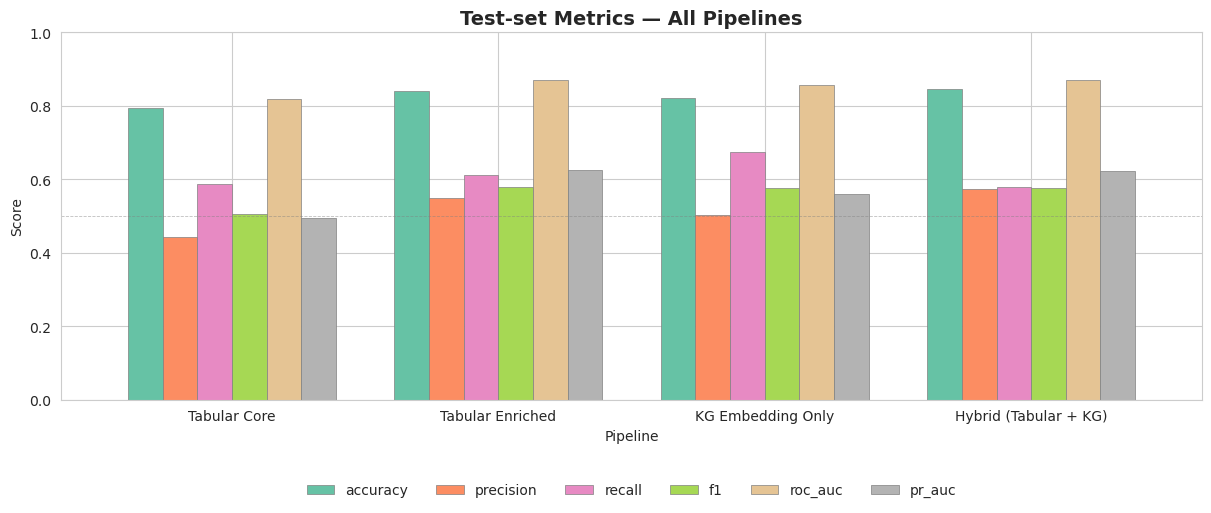

In [ ]:
if plt is not None and not comparison_df.empty:
    plot_df = comparison_df.set_index('Pipeline')[metric_keys]

    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
    plot_df.plot(kind='bar', ax=ax, width=0.78, colormap='Set2', edgecolor='grey', linewidth=0.5)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    ax.set_title('Test-set Metrics — All Pipelines', fontsize=14, fontweight='bold')
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.30), ncol=6, frameon=False)
    plt.xticks(rotation=0)
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.6, alpha=0.5)
    plt.show()

## 3. ROC-AUC and PR-AUC Focus

These are the most informative metrics for imbalanced heart-disease classification.

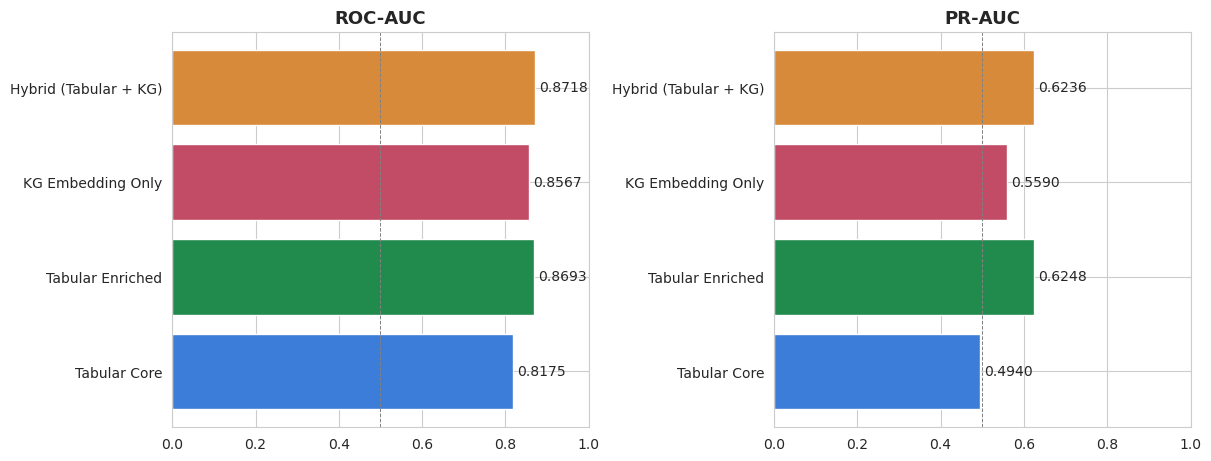

In [ ]:
if plt is not None and not comparison_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    colors = ['#3B7DD8', '#218A4D', '#C24B65', '#D88A3B']

    for ax, metric, title in zip(axes, ['roc_auc', 'pr_auc'], ['ROC-AUC', 'PR-AUC']):
        vals = comparison_df.set_index('Pipeline')[metric]
        bars = ax.barh(vals.index, vals.values, color=colors[:len(vals)])
        ax.set_xlim(0, 1)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.7)
        for bar, v in zip(bars, vals.values):
            ax.text(v + 0.01, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=10)
    plt.show()

## 4. Hybrid Model Details

The hybrid model concatenates the best tabular features with KG node embeddings (dataset + population-group + indicator embeddings from PyKEEN). This tests whether semantic graph context complements raw indicators.

In [ ]:
if hybrid_report:
    print(f"Selected model:      {hybrid_report['selected_model']}")
    print(f"Rows train / test:   {hybrid_report.get('rows_train', '?')} / {hybrid_report.get('rows_test', '?')}")
    print(f"Decision threshold:  {hybrid_report.get('decision_threshold', '?'):.4f}")
    print(f"\nCandidate models (CV PR-AUC):")
    for model_name, scores in hybrid_report.get('candidate_models', {}).items():
        mean = scores.get('cv_pr_auc_mean', scores.get('cv_roc_auc_mean', 0))
        std = scores.get('cv_pr_auc_std', scores.get('cv_roc_auc_std', 0))
        print(f"  {model_name:30s}  {mean:.4f} ± {std:.4f}")

Selected model:      logreg_hybrid
Rows train / test:   24000 / 6000
Decision threshold:  0.7196

Candidate models (CV PR-AUC):
  logreg_hybrid                   0.6411 ± 0.0039
  rf_hybrid                       0.6334 ± 0.0032
  gbm_hybrid                      0.6321 ± 0.0084


## 5. KG Embedding Training Summary (PyKEEN)

The graph was embedded using PyKEEN's DistMult model on the RDF triples (excluding outcome nodes to prevent leakage).

In [ ]:
if kg_report and 'pykeen_training' in kg_report:
    pykeen = kg_report['pykeen_training']
    pykeen_df = pd.DataFrame([pykeen]).T
    pykeen_df.columns = ['Value']
    pykeen_df

## 6. Improvement Analysis: Hybrid vs Tabular Baseline

How much does the KG add on top of the best tabular model?

In [ ]:
if hybrid_report and enriched_report:
    baseline = enriched_report['test_metrics']
    hybrid_m = hybrid_report['test_metrics']

    delta_rows = []
    for k in metric_keys:
        b = baseline.get(k, 0)
        h = hybrid_m.get(k, 0)
        delta_rows.append({
            'Metric': k,
            'Tabular Enriched': f'{b:.4f}',
            'Hybrid (Tab+KG)': f'{h:.4f}',
            'Δ (absolute)': f'{h - b:+.4f}',
            'Δ (%)': f'{(h - b) / b * 100:+.2f}%' if b > 0 else 'N/A',
        })

    delta_df = pd.DataFrame(delta_rows)
    delta_df

## 7. Conclusion

Key findings from the full comparison:

1. **Tabular Enriched** establishes a strong baseline thanks to rich clinical features.
2. **KG Embedding Only** achieves competitive performance using *only* graph-derived features — validating that the KG captures meaningful disease structure.
3. **Hybrid (Tabular + KG)** combines both worlds. The delta over the tabular baseline indicates whether the graph provides complementary signal.
4. The Knowledge Graph adds value primarily by encoding **relational context** (which population groups share risk factors, how indicators co-occur across datasets) that raw features alone don't capture.

In [ ]:
# Final summary from the comparison report
if comparison_report:
    print("=" * 60)
    print("MODEL COMPARISON REPORT SUMMARY")
    print("=" * 60)
    print(f"Generated: {comparison_report.get('run_at_utc', '?')}")
    print(f"Purpose:   {comparison_report.get('purpose', '?')[:120]}...")
    print(f"Pipelines compared: {len(comparison_report.get('pipelines', []))}")
    if 'conclusion' in comparison_report:
        print(f"\nConclusion: {comparison_report['conclusion']}")

MODEL COMPARISON REPORT SUMMARY
Generated: 2026-06-03T13:24:58+00:00
Purpose:   Direct comparison between traditional tabular ML pipelines and KG embedding-based classification to evaluate the added v...
Pipelines compared: 4
